In [2]:
#Odstranovanie odlahlych hodnot

        Premenna            Test     pPred       pPo   dPred     dPo
0   Dospelí váha  Mann-Whitney U  0.000000  0.000000  0.4945  0.6731
1  Dospelí výška    Welch t-test  0.000000  0.000000  1.8558  2.3549
2    Dospelí BMI  Mann-Whitney U  0.000263  0.000034  0.1418  0.1731
3      Deti váha  Mann-Whitney U  0.493627  0.493385  0.0728  0.0714
4     Deti výška  Mann-Whitney U  0.001567  0.001567  0.1138  0.1138
5       Deti BMI  Mann-Whitney U  0.290647  0.255265  0.0258  0.0349


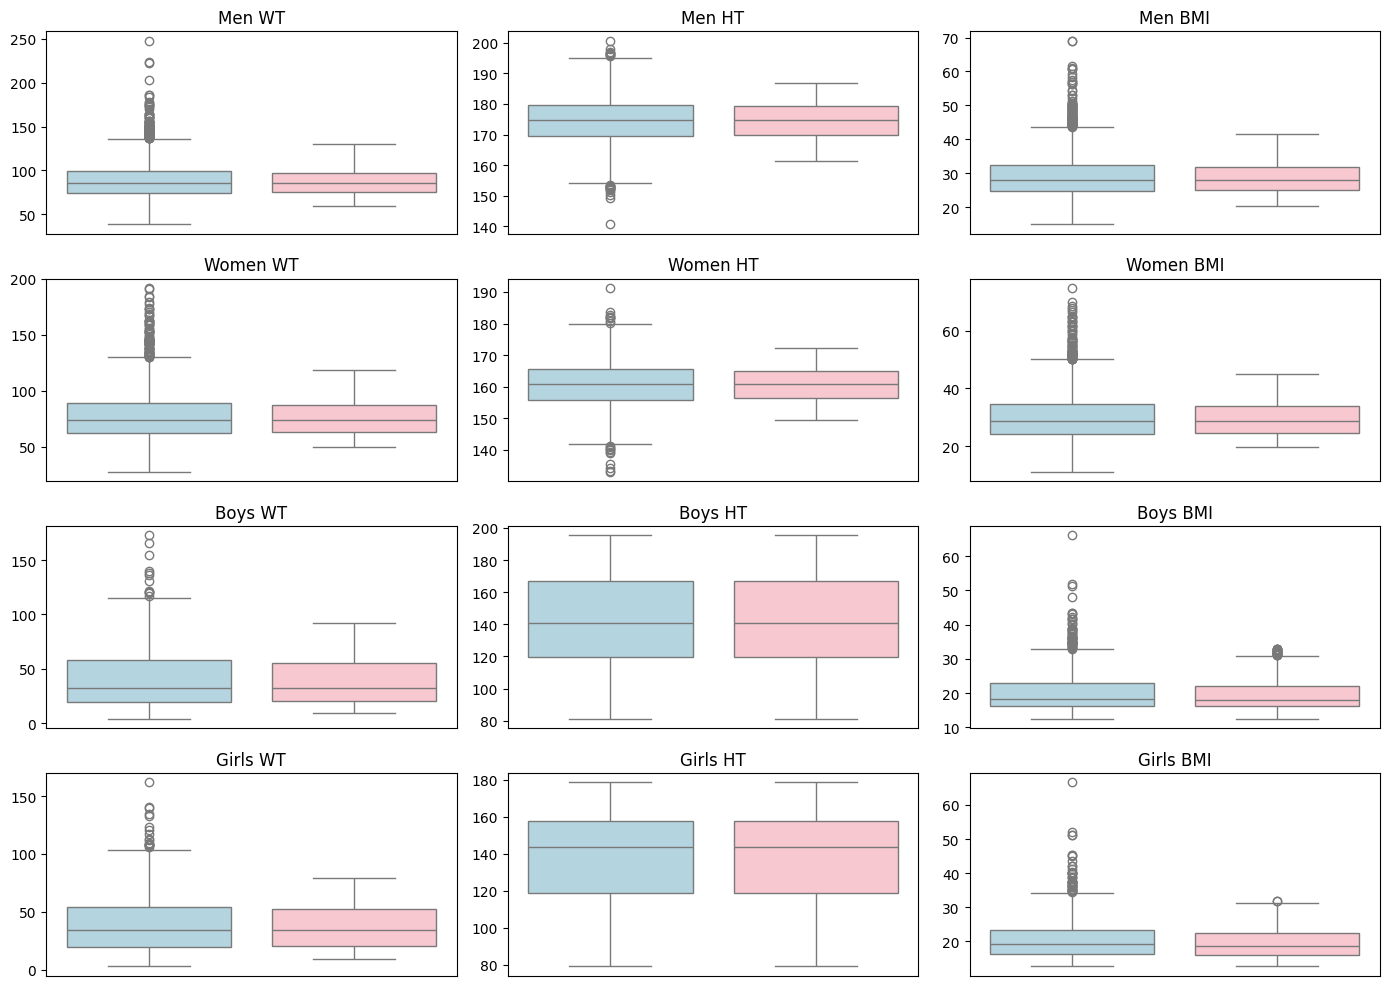

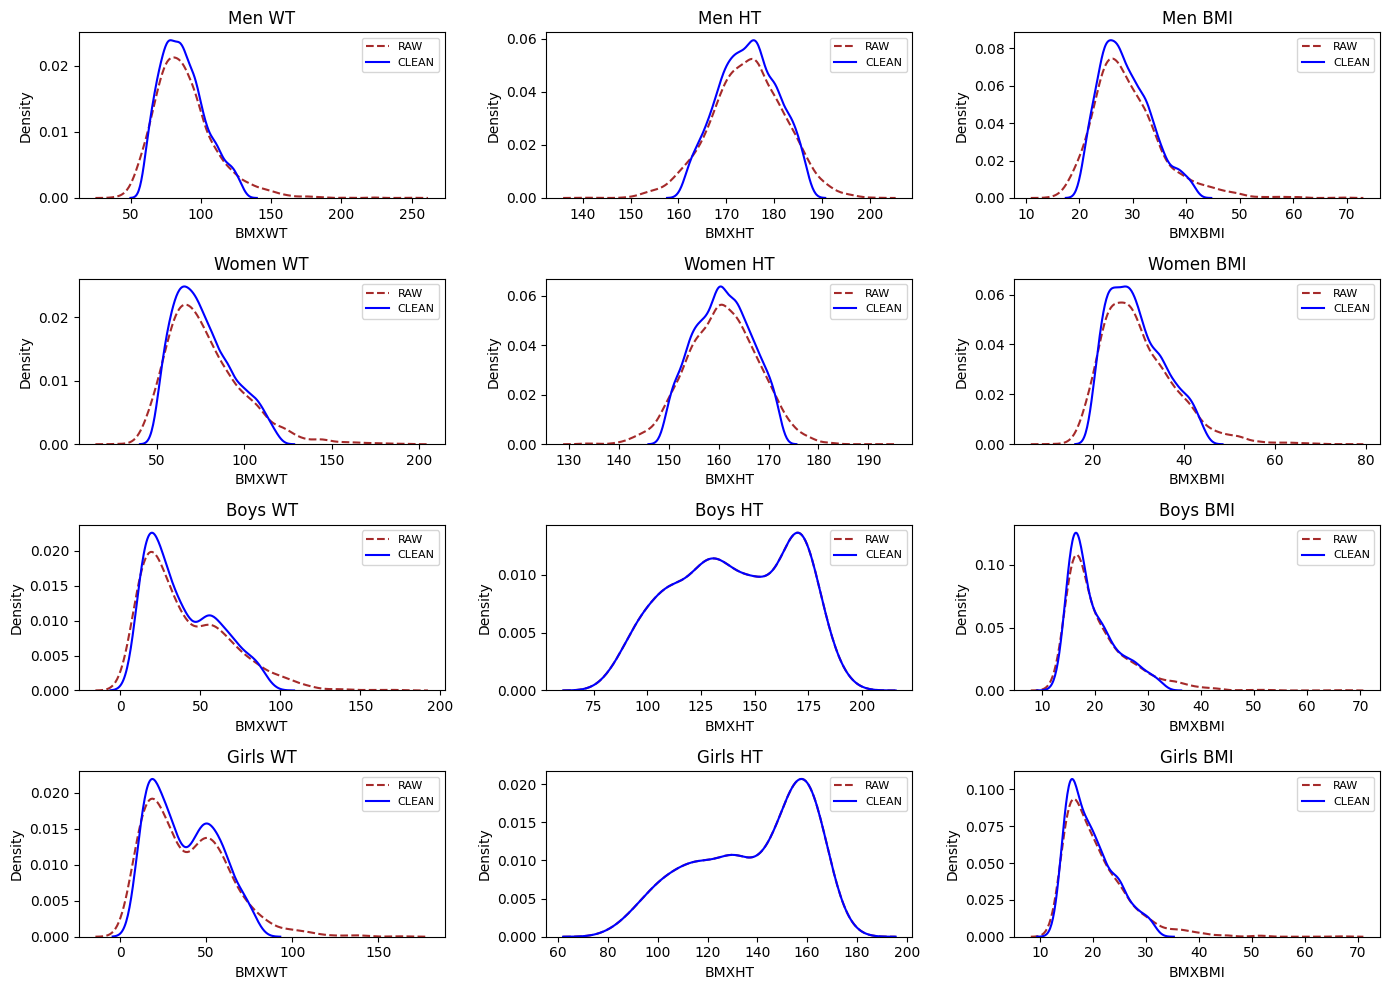

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro, mannwhitneyu, ttest_ind
import sys
import os

sys.path.append(os.path.abspath(".."))
import settings


def load_file(file_path):
    return pd.read_sas(file_path, format='xport')

def merge_files(file1, file2):
    return pd.merge(file1, file2[['SEQN','RIDAGEYR','RIAGENDR']], 
                    on='SEQN', how='left')

def remove_outliers(series, lower_q=0.05, upper_q=0.95):
    lower = series.quantile(lower_q)
    upper = series.quantile(upper_q)
    return series[(series >= lower) & (series <= upper)]

import numpy as np

def cohen_d(g1, g2):
    # pocet pozorovani
    n1, n2 = len(g1), len(g2)
    
    mean1, mean2 = np.mean(g1), np.mean(g2)
    var1, var2 = np.var(g1, ddof=1), np.var(g2, ddof=1)

    #smerodajna odchylka
    sp = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))

    return abs((mean1 - mean2) / sp)

def choose_test(group1, group2):
    g1, g2 = group1.dropna(), group2.dropna()
    if len(g1) < 3 or len(g2) < 3: return "N/A", 1.0

    p1 = shapiro(g1.sample(min(len(g1), 500), random_state=42))[1]
    p2 = shapiro(g2.sample(min(len(g2), 500), random_state=42))[1]

    if p1 > 0.05 and p2 > 0.05:
        stat, p = ttest_ind(g1, g2, equal_var=False)
        return "Welch t-test", p
    else:
        stat, p = mannwhitneyu(g1, g2, alternative='two-sided')
        return "Mann-Whitney U", p

def get_stats(name, raw1, raw2, clean1, clean2):
    test_before, p_before = choose_test(raw1, raw2)
    test_after, p_after = choose_test(clean1, clean2)
    d_before = cohen_d(raw1, raw2)
    d_after = cohen_d(clean1, clean2)

    return {
        "Premenna": name,
        "Test": test_before,
        "pPred": round(p_before, 6),
        "pPo": round(p_after, 6),
        "dPred": round(d_before, 4),
        "dPo": round(d_after, 4)
    }

bmx = load_file(settings.bmx_path)
demo = load_file(settings.demo_path)
data = merge_files(bmx, demo)

adults = data[data['RIDAGEYR'] >= 18]
children = data[data['RIDAGEYR'] < 18]

# Príprava segmentov
mWT_a = adults[adults['RIAGENDR']==1]['BMXWT'].dropna()
wWT_a = adults[adults['RIAGENDR']==2]['BMXWT'].dropna()
mHT_a = adults[adults['RIAGENDR']==1]['BMXHT'].dropna()
wHT_a = adults[adults['RIAGENDR']==2]['BMXHT'].dropna()
mBMI_a = adults[adults['RIAGENDR']==1]['BMXBMI'].dropna()
wBMI_a = adults[adults['RIAGENDR']==2]['BMXBMI'].dropna()

mWT_c = children[children['RIAGENDR']==1]['BMXWT'].dropna()
wWT_c = children[children['RIAGENDR']==2]['BMXWT'].dropna()
mHT_c = children[children['RIAGENDR']==1]['BMXHT'].dropna()
wHT_c = children[children['RIAGENDR']==2]['BMXHT'].dropna()
mBMI_c = children[children['RIAGENDR']==1]['BMXBMI'].dropna()
wBMI_c = children[children['RIAGENDR']==2]['BMXBMI'].dropna()

mBMI_c_hack = mBMI_c[mBMI_c <= mBMI_c.quantile(0.95)]
wBMI_c_hack = wBMI_c[wBMI_c <= wBMI_c.quantile(0.95)]

results_list = []
results_list.append(get_stats("Dospelí váha", mWT_a, wWT_a, remove_outliers(mWT_a), remove_outliers(wWT_a)))
results_list.append(get_stats("Dospelí výška", mHT_a, wHT_a, remove_outliers(mHT_a), remove_outliers(wHT_a)))
results_list.append(get_stats("Dospelí BMI", mBMI_a, wBMI_a, remove_outliers(mBMI_a), remove_outliers(wBMI_a)))
results_list.append(get_stats("Deti váha", mWT_c, wWT_c, remove_outliers(mWT_c), remove_outliers(wWT_c)))
results_list.append(get_stats("Deti výška", mHT_c, wHT_c, mHT_c, wHT_c))
results_list.append(get_stats("Deti BMI", mBMI_c, wBMI_c, mBMI_c_hack, wBMI_c_hack))

all_stats_df = pd.DataFrame(results_list)

# tabulka p-hodnot
p_values_df = all_stats_df[["Premenna", "Test", "pPred", "pPo"]]
p_values_df.to_csv("outlier_comparison_table.csv", index=False)

# tabulka cohen d
cohen_df = all_stats_df[["Premenna", "dPred", "dPo"]]
cohen_df.to_csv("cohen_effect_size_table.csv", index=False)

print(all_stats_df)

# vizualizacia
datasets = [
    (mWT_a, remove_outliers(mWT_a), "Men WT"), (mHT_a, remove_outliers(mHT_a), "Men HT"), (mBMI_a, remove_outliers(mBMI_a), "Men BMI"),
    (wWT_a, remove_outliers(wWT_a), "Women WT"), (wHT_a, remove_outliers(wHT_a), "Women HT"), (wBMI_a, remove_outliers(wBMI_a), "Women BMI"),
    (mWT_c, remove_outliers(mWT_c), "Boys WT"), (mHT_c, mHT_c, "Boys HT"), (mBMI_c, mBMI_c_hack, "Boys BMI"),
    (wWT_c, remove_outliers(wWT_c), "Girls WT"), (wHT_c, wHT_c, "Girls HT"), (wBMI_c, wBMI_c_hack, "Girls BMI")
]

ncols = 3
nrows = 4

# boxplot
fig1, axes1 = plt.subplots(nrows, ncols, figsize=(14, 10))
axes1 = axes1.flatten()
for i, (raw, clean, title) in enumerate(datasets):
    df_plot = pd.DataFrame({"RAW": pd.Series(raw).reset_index(drop=True), "CLEAN": pd.Series(clean).reset_index(drop=True)})
    sns.boxplot(data=df_plot, ax=axes1[i], palette=["lightblue", "pink"])
    axes1[i].set_title(title)
    axes1[i].set_xticks([])
plt.tight_layout()
plt.savefig("ALL_BOXPLOT_IN_ONE.png", dpi=300)

# kdeplot
fig2, axes2 = plt.subplots(nrows, ncols, figsize=(14, 10))
axes2 = axes2.flatten()
for i, (raw, clean, title) in enumerate(datasets):
    sns.kdeplot(raw, color="brown", ax=axes2[i], label="RAW", ls="--")
    sns.kdeplot(clean, color="blue", ax=axes2[i], label="CLEAN")
    axes2[i].set_title(title)
    axes2[i].legend(fontsize=8)
plt.tight_layout()
plt.savefig("ALL_KDE_IN_ONE.png", dpi=300)

plt.show()

